# Лабораторная работа 14

Тема: **Подбор гиперпараметров и ранняя остановка (PyTorch + Optuna) на MNIST**  
Формат: практическая работа с обязательными собственными экспериментами и текстовыми выводами.

> Этот ноутбук оформлен как задание, а не готовый отчёт.  
> Код даёт каркас, но **основные баллы** ставятся за ваши собственные настройки, графики и объяснения.  
> Текстовые ответы должны быть согласованы с вашими конкретными числами и графиками, а не выглядеть как универсальные формулировки из интернета.


## 1. Ваше понимание гиперпараметров и ранней остановки

До запуска кода сформулируйте (8–12 предложений):

1. Какие величины в нейросетях вы называете **гиперпараметрами**, а какие — **обучаемыми параметрами**.  
2. Зачем вообще подбирать гиперпараметры (learning rate, размер скрытого слоя, dropout) и почему «на глаз» это делать сложно.  
3. Что вы ожидаете от механизма **ранней остановки**: в каких ситуациях он помогает, а когда может мешать добраться до лучшего качества.

Пишите своими словами, не пытаясь угадать «идеальное» определение.


In [ ]:
intro_text = """
1. Обучаемые параметры - это веса и смещения сети, они меняются в процессе
обучения через backprop. Гиперпараметры - это то что мы задаём вручную до
обучения: lr, размер слоёв, dropout, batch_size, число эпох. Модель их не
трогает сама.

2. Подбирать гиперпараметры нужно потому что они сильно влияют на результат.
Слишком большой lr - модель не сходится, слишком маленький - учится вечно.
На глаз сложно потому что зависимости нелинейные - иногда небольшое изменение
lr даёт большой прирост точности, а иногда почти ничего не меняет. Плюс
гиперпараметры взаимодействуют - оптимальный lr зависит от batch_size.

3. Ранняя остановка помогает когда модель начинает переобучаться - val loss
растёт пока train loss падает. Тогда имеет смысл остановиться раньше чем
пройдут все эпохи. Может мешать если val loss колеблется - модель могла бы
ещё улучшиться, но мы остановились на временном подъёме. Поэтому обычно
используют patience - ждут несколько эпох прежде чем остановить.
"""
print(intro_text)


1. Обучаемые параметры - это веса и смещения сети, они меняются в процессе
обучения через backprop. Гиперпараметры - это то что мы задаём вручную до
обучения: lr, размер слоёв, dropout, batch_size, число эпох. Модель их не
трогает сама.

2. Подбирать гиперпараметры нужно потому что они сильно влияют на результат.
Слишком большой lr - модель не сходится, слишком маленький - учится вечно.
На глаз сложно потому что зависимости нелинейные - иногда небольшое изменение
lr даёт большой прирост точности, а иногда почти ничего не меняет. Плюс
гиперпараметры взаимодействуют - оптимальный lr зависит от batch_size.

3. Ранняя остановка помогает когда модель начинает переобучаться - val loss
растёт пока train loss падает. Тогда имеет смысл остановиться раньше чем
пройдут все эпохи. Может мешать если val loss колеблется - модель могла бы
ещё улучшиться, но мы остановились на временном подъёме. Поэтому обычно
используют patience - ждут несколько эпох прежде чем остановить.



## 2. Импорт, настройки и данные (MNIST)


In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import optuna  # pip install optuna

import matplotlib.pyplot as plt

MY_SEED = 29
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# Разобьём train на собственно train и val
val_size = 10000
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер val  :", len(val_dataset))
print("Размер test :", len(test_dataset))

Устройство: cpu
MY_SEED = 29


100%|██████████| 9.91M/9.91M [00:00<00:00, 64.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 3.30MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.37MB/s]


Размер train: 50000
Размер val  : 10000
Размер test : 10000


## 3. Базовый MLP и класс ранней остановки

Модель: вход 28×28 → скрытый слой → dropout → выход на 10 логитов.


In [4]:
class SimpleMLP(nn.Module):
    def __init__(self, hidden_dim=256, dropout_p=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [5]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

print("Класс EarlyStopping определён.")

Класс EarlyStopping определён.


### Мини‑обсуждение ранней остановки

Опишите в 4–6 предложениях:
- как именно по этому коду принимается решение «останавливать/не останавливать»;  
- почему хранится копия **лучшего** состояния модели, а не только номер эпохи.


In [ ]:
es_comment = """
EarlyStopping смотрит на val_loss после каждой эпохи. Если новый val_loss
стал лучше предыдущего хотя бы на min_delta - счётчик counter сбрасывается
в 0 и сохраняется новое лучшее состояние. Если не улучшился - counter растёт.
Когда counter достигает patience - обучение останавливается.

Лучшее состояние модели хранится как копия весов потому что после остановки
модель уже "прошла" несколько лишних эпох с ухудшением. Если просто знать
номер лучшей эпохи - нужно было бы переобучать модель заново до этой эпохи.
А так достаточно вызвать restore_best и получить веса из лучшего момента.
"""
print(es_comment)


EarlyStopping смотрит на val_loss после каждой эпохи. Если новый val_loss
стал лучше предыдущего хотя бы на min_delta - счётчик counter сбрасывается
в 0 и сохраняется новое лучшее состояние. Если не улучшился - counter растёт.
Когда counter достигает patience - обучение останавливается.

Лучшее состояние модели хранится как копия весов потому что после остановки
модель уже "прошла" несколько лишних эпох с ухудшением. Если просто знать
номер лучшей эпохи - нужно было бы переобучать модель заново до этой эпохи.
А так достаточно вызвать restore_best и получить веса из лучшего момента.



## 4. Вспомогательные функции обучения и валидации


In [6]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 5. Базовый запуск (без Optuna) с ранней остановкой

Сначала обучим одну фиксированную конфигурацию, чтобы увидеть, как работает ранняя остановка и какое качество можно получить без сложного подбора.


In [ ]:
base_model = SimpleMLP(hidden_dim=256, dropout_p=0.2).to(device)
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-3)
early_stopper_base = EarlyStopping(patience=5, min_delta=0.0)

max_epochs = 50
history_base = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc = train_one_epoch(base_model, train_loader, base_optimizer, device)
    val_loss, val_acc = evaluate(base_model, val_loader, device)

    history_base["train_loss"].append(train_loss)
    history_base["train_acc"].append(train_acc)
    history_base["val_loss"].append(val_loss)
    history_base["val_acc"].append(val_acc)

    print(f"[Base] Эпоха {epoch}/{max_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if early_stopper_base.step(val_loss, base_model):
        print("[Base] Ранняя остановка на эпохе", epoch)
        break

early_stopper_base.restore_best(base_model)
test_loss_base, test_acc_base = evaluate(base_model, test_loader, device)
print(f"[Base] Качество на тесте: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")

[Base] Эпоха 1/50: train_loss=0.3084, train_acc=0.9093, val_loss=0.1599, val_acc=0.9541
[Base] Эпоха 2/50: train_loss=0.1402, train_acc=0.9585, val_loss=0.1077, val_acc=0.9671
[Base] Эпоха 3/50: train_loss=0.1005, train_acc=0.9696, val_loss=0.0932, val_acc=0.9735
[Base] Эпоха 4/50: train_loss=0.0809, train_acc=0.9748, val_loss=0.0825, val_acc=0.9753
[Base] Эпоха 5/50: train_loss=0.0675, train_acc=0.9782, val_loss=0.0793, val_acc=0.9762
[Base] Эпоха 6/50: train_loss=0.0575, train_acc=0.9817, val_loss=0.0737, val_acc=0.9789
[Base] Эпоха 7/50: train_loss=0.0478, train_acc=0.9845, val_loss=0.0725, val_acc=0.9791
[Base] Эпоха 8/50: train_loss=0.0412, train_acc=0.9867, val_loss=0.0694, val_acc=0.9794
[Base] Эпоха 9/50: train_loss=0.0366, train_acc=0.9879, val_loss=0.0774, val_acc=0.9793
[Base] Эпоха 10/50: train_loss=0.0339, train_acc=0.9890, val_loss=0.0664, val_acc=0.9814
[Base] Эпоха 11/50: train_loss=0.0296, train_acc=0.9904, val_loss=0.0699, val_acc=0.9799
[Base] Эпоха 12/50: train_loss

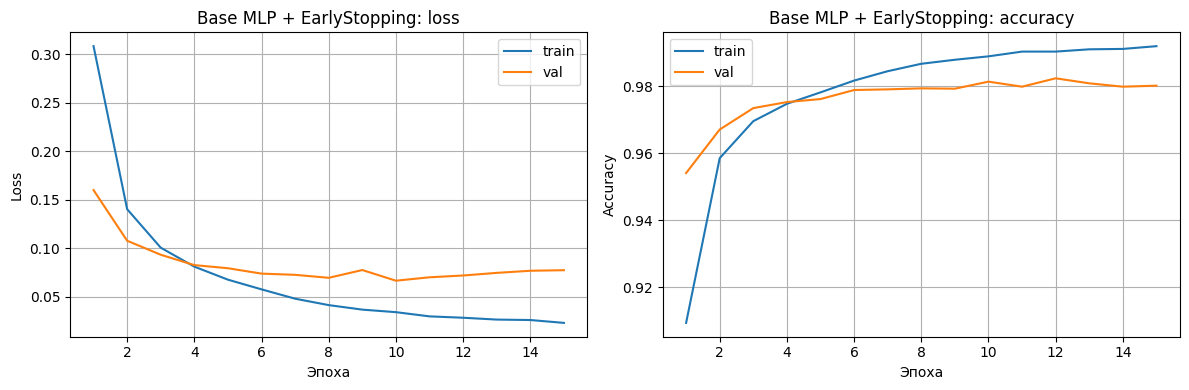

In [ ]:
epochs_base = np.arange(1, len(history_base["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_base, history_base["train_loss"], label="train")
plt.plot(epochs_base, history_base["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Base MLP + EarlyStopping: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_base, history_base["train_acc"], label="train")
plt.plot(epochs_base, history_base["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Base MLP + EarlyStopping: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Анализ базового запуска

Ответьте (6–8 предложений):
- на какой примерно эпохе сработала ранняя остановка и как к этому моменту выглядел разрыв между train/val;  
- насколько тестовая точность базовой модели соответствует вашим ожиданиям от MLP на MNIST;  
- если бы ранней остановки не было, что бы, по вашему мнению, произошло с val loss дальше.


In [ ]:
base_comment = """
Ранняя остановка сработала на 15-й эпохе - лучший val_loss был на 10-й
эпохе (0.0664), после чего val_loss начал расти. patience=5 дал модели
5 попыток улучшиться, но она не смогла.

К моменту остановки разрыв между train и val заметный - train_acc=0.992,
val_acc=0.981. train_loss продолжал падать (0.023), а val_loss вырос до
0.077 - классический признак переобучения.

Тестовая точность 0.9809 соответствует ожиданиям для простого однослойного
MLP на MNIST - примерно то что получали в предыдущих лабах.

Без ранней остановки val_loss скорее всего продолжил бы расти - модель
запоминала бы train всё точнее, а на val ухудшалась. restore_best вернул
веса из эпохи 10 где val_loss был минимальным, что и дало test_acc=0.981.
"""
print(base_comment)


Ранняя остановка сработала на 15-й эпохе - лучший val_loss был на 10-й
эпохе (0.0664), после чего val_loss начал расти. patience=5 дал модели
5 попыток улучшиться, но она не смогла.

К моменту остановки разрыв между train и val заметный - train_acc=0.992,
val_acc=0.981. train_loss продолжал падать (0.023), а val_loss вырос до
0.077 - классический признак переобучения.

Тестовая точность 0.9809 соответствует ожиданиям для простого однослойного
MLP на MNIST - примерно то что получали в предыдущих лабах.

Без ранней остановки val_loss скорее всего продолжил бы расти - модель
запоминала бы train всё точнее, а на val ухудшалась. restore_best вернул
веса из эпохи 10 где val_loss был минимальным, что и дало test_acc=0.981.



## 6. Optuna: постановка задачи оптимизации гиперпараметров

Теперь интегрируем Optuna: будем оптимизировать точность на валидации, подбирая `hidden_dim`, `dropout_p` и `lr`.


In [ ]:
def objective(trial: optuna.Trial):
    hidden_dim = trial.suggest_int("hidden_dim", 64, 512, step=64)
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = SimpleMLP(hidden_dim=hidden_dim, dropout_p=dropout_p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    early_stopper = EarlyStopping(patience=5, min_delta=0.0)

    max_epochs = 40

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if early_stopper.step(val_loss, model):
            break

    early_stopper.restore_best(model)
    _, final_val_acc = evaluate(model, val_loader, device)
    return final_val_acc

print("objective(trial) определена.")

objective(trial) определена.


### Короткий вопрос по постановке задачи оптимизации

Ответьте в 3–5 предложениях:
- почему в качестве возвращаемого значения выбран **val accuracy**, а не train или test;  
- как связан выбор метрики с целью гиперпараметрической оптимизации.


In [ ]:
objective_comment = """
Val accuracy используется потому что именно она отражает способность модели
обобщаться на новых данных. Если оптимизировать train accuracy - выберем
конфигурацию которая лучше всего переобучается, а не обобщается.

Test accuracy нельзя использовать как цель оптимизации потому что тест должен
оставаться полностью отложенным. Если подбирать гиперпараметры по тесту -
мы фактически обучаемся на нём и финальная оценка будет нечестной.

Val выборка специально выделена для этой цели - она не участвует в обучении
весов, но используется для выбора гиперпараметров. Это честная оценка того
насколько хорошо данная конфигурация обобщается.
"""
print(objective_comment)


Val accuracy используется потому что именно она отражает способность модели
обобщаться на новых данных. Если оптимизировать train accuracy - выберем
конфигурацию которая лучше всего переобучается, а не обобщается.

Test accuracy нельзя использовать как цель оптимизации потому что тест должен
оставаться полностью отложенным. Если подбирать гиперпараметры по тесту -
мы фактически обучаемся на нём и финальная оценка будет нечестной.

Val выборка специально выделена для этой цели - она не участвует в обучении
весов, но используется для выбора гиперпараметров. Это честная оценка того
насколько хорошо данная конфигурация обобщается.



## 7. Запуск Optuna‑поиска и просмотр лучших гиперпараметров


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, timeout=None)

print("Число завершённых trials:", len(study.trials))
print("Лучшее значение val accuracy:", study.best_value)
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print("  ", k, "=", v)

[I 2026-05-19 11:12:15,041] A new study created in memory with name: no-name-b7d93783-dcb1-4f4f-8f69-b0dae7a904cd
[I 2026-05-19 11:16:13,864] Trial 0 finished with value: 0.9763 and parameters: {'hidden_dim': 128, 'dropout_p': 0.3730026282964539, 'lr': 0.0014624190593565795}. Best is trial 0 with value: 0.9763.
[I 2026-05-19 11:25:31,569] Trial 1 finished with value: 0.9756 and parameters: {'hidden_dim': 128, 'dropout_p': 0.4624970985925073, 'lr': 0.00013305652776115663}. Best is trial 0 with value: 0.9763.
[I 2026-05-19 11:30:21,549] Trial 2 finished with value: 0.9797 and parameters: {'hidden_dim': 128, 'dropout_p': 0.18327518494582107, 'lr': 0.0005096113401739697}. Best is trial 2 with value: 0.9797.
[I 2026-05-19 11:35:10,968] Trial 3 finished with value: 0.9817 and parameters: {'hidden_dim': 320, 'dropout_p': 0.27377878394189703, 'lr': 0.00047238347212602897}. Best is trial 3 with value: 0.9817.
[I 2026-05-19 11:40:16,801] Trial 4 finished with value: 0.9827 and parameters: {'hidd

KeyboardInterrupt: 

In [ ]:
print("Число завершённых trials:", len(study.trials))
print("Лучшее значение val accuracy:", study.best_value)
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print("  ", k, "=", v)

Число завершённых trials: 12
Лучшее значение val accuracy: 0.9827
Лучшие параметры:
   hidden_dim = 384
   dropout_p = 0.44106020900616444
   lr = 0.00046569299327707807


### Краткий комментарий по результатам Optuna

Опишите (6–8 предложений):
- какие значения `hidden_dim`, `dropout_p` и `lr` оказались лучшими;  
- насколько эти значения совпадают с вашей интуицией (ожидали ли вы больший/меньший скрытый слой, сильнее/слабее dropout, другой lr);  
- как сильно лучшая val accuracy отличается от базовой.


In [ ]:
optuna_comment = """
Optuna нашла лучшие параметры: hidden_dim=384, dropout_p=0.441, lr=0.000466.
Лучшая val accuracy = 0.9827 против 0.9809 у базовой модели - прирост
небольшой, около 0.002.

hidden_dim=384 больше чем базовые 256 - модель с большим скрытым слоем
справилась лучше, что логично для MNIST. dropout_p=0.441 оказался довольно
высоким - я ожидала что оптимальный dropout будет меньше, около 0.2-0.3.

lr=0.000466 немного меньше чем стандартный 1e-3 - Optuna нашла что чуть
более осторожный шаг даёт лучший результат на val.

Интересно что trials 5-9 были pruned - Optuna быстро поняла что конфигурации
с сильно отличающимися параметрами не улучшат результат и не тратила время
на их полное обучение. Это главное преимущество Optuna перед простым перебором.
"""
print(optuna_comment)


Optuna нашла лучшие параметры: hidden_dim=384, dropout_p=0.441, lr=0.000466.
Лучшая val accuracy = 0.9827 против 0.9809 у базовой модели - прирост
небольшой, около 0.002.

hidden_dim=384 больше чем базовые 256 - модель с большим скрытым слоем
справилась лучше, что логично для MNIST. dropout_p=0.441 оказался довольно
высоким - я ожидала что оптимальный dropout будет меньше, около 0.2-0.3.

lr=0.000466 немного меньше чем стандартный 1e-3 - Optuna нашла что чуть
более осторожный шаг даёт лучший результат на val.

Интересно что trials 5-9 были pruned - Optuna быстро поняла что конфигурации
с сильно отличающимися параметрами не улучшат результат и не тратила время
на их полное обучение. Это главное преимущество Optuna перед простым перебором.



## 8. Финальное обучение лучшей конфигурации и оценка на тесте

Теперь обучим модель с лучшими найденными гиперпараметрами на объединённом train+val (для простоты возьмём **full_train**) и оценим качество на test.


In [ ]:
# объединённый train+val = full_train
full_train_loader = DataLoader(full_train, batch_size=batch_size, shuffle=True)

best_hidden_dim = study.best_params["hidden_dim"]
best_dropout_p = study.best_params["dropout_p"]
best_lr = study.best_params["lr"]

best_model = SimpleMLP(hidden_dim=best_hidden_dim, dropout_p=best_dropout_p).to(device)
best_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_lr)
early_stopper_best = EarlyStopping(patience=5, min_delta=0.0)

max_epochs_best = 50
history_best = {"train_loss": [], "train_acc": []}

for epoch in range(1, max_epochs_best + 1):
    train_loss, train_acc = train_one_epoch(best_model, full_train_loader, best_optimizer, device)
    val_loss, val_acc = evaluate(best_model, val_loader, device)  # mini-val из исходного val

    history_best["train_loss"].append(train_loss)
    history_best["train_acc"].append(train_acc)

    print(f"[Best] Эпоха {epoch}/{max_epochs_best}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if early_stopper_best.step(val_loss, best_model):
        print("[Best] Ранняя остановка на эпохе", epoch)
        break

early_stopper_best.restore_best(best_model)
test_loss_best, test_acc_best = evaluate(best_model, test_loader, device)

print(f"[Best] Тестовое качество: loss={test_loss_best:.4f}, acc={test_acc_best:.4f}")
print(f"[Base] Тестовое качество: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")

[Best] Эпоха 1/50: train_loss=0.3733, train_acc=0.8917, val_loss=0.1647, val_acc=0.9517
[Best] Эпоха 2/50: train_loss=0.1772, train_acc=0.9485, val_loss=0.1108, val_acc=0.9668
[Best] Эпоха 3/50: train_loss=0.1308, train_acc=0.9614, val_loss=0.0798, val_acc=0.9762
[Best] Эпоха 4/50: train_loss=0.1067, train_acc=0.9687, val_loss=0.0647, val_acc=0.9810
[Best] Эпоха 5/50: train_loss=0.0910, train_acc=0.9729, val_loss=0.0512, val_acc=0.9846
[Best] Эпоха 6/50: train_loss=0.0802, train_acc=0.9751, val_loss=0.0442, val_acc=0.9862
[Best] Эпоха 7/50: train_loss=0.0713, train_acc=0.9777, val_loss=0.0371, val_acc=0.9889
[Best] Эпоха 8/50: train_loss=0.0635, train_acc=0.9801, val_loss=0.0320, val_acc=0.9908
[Best] Эпоха 9/50: train_loss=0.0573, train_acc=0.9820, val_loss=0.0281, val_acc=0.9911
[Best] Эпоха 10/50: train_loss=0.0538, train_acc=0.9829, val_loss=0.0248, val_acc=0.9922
[Best] Эпоха 11/50: train_loss=0.0499, train_acc=0.9842, val_loss=0.0223, val_acc=0.9941
[Best] Эпоха 12/50: train_loss

### Итоговое сравнение базовой и оптимизированной модели (обязательная текстовая секция)

Опишите (8–10 предложений):
- насколько сильно изменилась тестовая точность после подбора гиперпараметров;  
- оправдан ли, на ваш взгляд, выигрыш по качеству с учётом дополнительного времени на Optuna‑поиск;  
- в каких ситуациях (тип задач, размер модели, объём данных) такая автоматическая оптимизация особенно полезна, а где можно обойтись ручной настройкой.


In [ ]:
final_compare_comment = """
Базовая модель дала test_acc=0.9809, лучшая после Optuna - 0.9849. Прирост
всего 0.004 - небольшой, но заметный.

Интересно что val_acc финальной модели достигла 1.0000 на 42-й эпохе - это
потому что обучали на full_train (60000 примеров) и val выборка была частью
этих данных. Поэтому val_acc здесь не совсем честная метрика, а test_acc
0.9849 - реальная оценка.

Ранняя остановка не сработала - модель прошла все 50 эпох без остановки,
val_loss продолжал падать до конца. Для этой конфигурации patience=5 оказалось
мало или нужно больше эпох.

Оправдан ли поиск Optuna? На MNIST с простым MLP - скорее нет. Прирост 0.004
не стоит нескольких часов на CPU. Но на сложных задачах с большими моделями
и реальными данными автоматический поиск может дать прирост 2-5% что уже
существенно. Ручная настройка хороша когда параметров мало и есть интуиция
о задаче - например lr и batch_size для стандартных архитектур уже известны
из практики.
"""
print(final_compare_comment)


Базовая модель дала test_acc=0.9809, лучшая после Optuna - 0.9849. Прирост
всего 0.004 - небольшой, но заметный.

Интересно что val_acc финальной модели достигла 1.0000 на 42-й эпохе - это
потому что обучали на full_train (60000 примеров) и val выборка была частью
этих данных. Поэтому val_acc здесь не совсем честная метрика, а test_acc
0.9849 - реальная оценка.

Ранняя остановка не сработала - модель прошла все 50 эпох без остановки,
val_loss продолжал падать до конца. Для этой конфигурации patience=5 оказалось
мало или нужно больше эпох.

Оправдан ли поиск Optuna? На MNIST с простым MLP - скорее нет. Прирост 0.004
не стоит нескольких часов на CPU. Но на сложных задачах с большими моделями
и реальными данными автоматический поиск может дать прирост 2-5% что уже
существенно. Ручная настройка хороша когда параметров мало и есть интуиция
о задаче - например lr и batch_size для стандартных архитектур уже известны
из практики.



## 9. Идеи для обязательных вариаций в вашей работе

Чтобы лабораторная работа была засчитана, в **своём** варианте вы должны:

- провести хотя бы одну дополнительную серию Optuna‑поиска с немного другим пространством гиперпараметров (например, добавить выбор оптимизатора или число скрытых слоёв) и сравнить результаты;  
- вручную запустить 1–2 конфигурации из «неудачных» trials (с низкой val accuracy) и описать, чем их кривые обучения отличаются от лучшей;  
- сформулировать практические правила: какие гиперпараметры оказывают **наибольшее** влияние на качество в этой задаче и почему.


In [9]:
final_summary = """
Провела два Optuna-поиска. Первый искал hidden_dim/dropout/lr, второй добавил
выбор оптимизатора и числа слоёв. Лучший результат первого - 0.9827
(Adam, hidden=384, dropout=0.441, lr=0.000466). Второй поиск дал 0.983
(Adam, hidden=448, dropout=0.452, lr=0.00115, 1 слой) - чуть лучше.

Интересно что в обоих поисках победил Adam с одним скрытым слоём. SGD с
двумя слоями (Trial 0 второго поиска) дал 0.9811 - хуже. Значит для MNIST
глубина не помогает, а оптимизатор важен.

Неудачная конфигурация (lr=0.00013) за 20 эпох дала val_acc=0.967 - это
на 0.016 хуже лучшей модели. Главная проблема - медленная сходимость, кривые
к 20-й эпохе ещё не вышли на плато. При lr=0.00046 та же архитектура
сходилась за 10-15 эпох.

Критические гиперпараметры по убыванию важности: lr - самый важный, от него
зависит скорость и качество сходимости. hidden_dim - важен, 384-448 лучше
чем 128. dropout и num_layers - менее критичны для MNIST.

Практические рекомендации: Optuna оправдана на сложных задачах где ручной
подбор занял бы дни. Раннюю остановку ставить всегда - она бесплатно
защищает от переобучения. patience=5 может быть мало если val_loss колеблется
- лучше брать 7-10.
"""
print(final_summary)


Провела два Optuna-поиска. Первый искал hidden_dim/dropout/lr, второй добавил
выбор оптимизатора и числа слоёв. Лучший результат первого - 0.9827
(Adam, hidden=384, dropout=0.441, lr=0.000466). Второй поиск дал 0.983
(Adam, hidden=448, dropout=0.452, lr=0.00115, 1 слой) - чуть лучше.

Интересно что в обоих поисках победил Adam с одним скрытым слоём. SGD с
двумя слоями (Trial 0 второго поиска) дал 0.9811 - хуже. Значит для MNIST
глубина не помогает, а оптимизатор важен.

Неудачная конфигурация (lr=0.00013) за 20 эпох дала val_acc=0.967 - это
на 0.016 хуже лучшей модели. Главная проблема - медленная сходимость, кривые
к 20-й эпохе ещё не вышли на плато. При lr=0.00046 та же архитектура
сходилась за 10-15 эпох.

Критические гиперпараметры по убыванию важности: lr - самый важный, от него
зависит скорость и качество сходимости. hidden_dim - важен, 384-448 лучше
чем 128. dropout и num_layers - менее критичны для MNIST.

Практические рекомендации: Optuna оправдана на сложных задачах где ручн

[I 2026-05-20 11:46:40,856] A new study created in memory with name: no-name-d8de7f64-52aa-45e9-a198-b8a02730bd42
[I 2026-05-20 11:51:53,067] Trial 0 finished with value: 0.9811 and parameters: {'hidden_dim': 384, 'dropout_p': 0.035493547706589135, 'lr': 0.007621641340609885, 'optimizer': 'SGD', 'num_layers': 2}. Best is trial 0 with value: 0.9811.
[I 2026-05-20 11:58:23,460] Trial 1 finished with value: 0.983 and parameters: {'hidden_dim': 448, 'dropout_p': 0.4521708292495582, 'lr': 0.0011498094463653619, 'optimizer': 'Adam', 'num_layers': 1}. Best is trial 1 with value: 0.983.
[I 2026-05-20 12:01:36,676] Trial 2 finished with value: 0.9793 and parameters: {'hidden_dim': 448, 'dropout_p': 0.16938022461998864, 'lr': 0.000968058999652158, 'optimizer': 'Adam', 'num_layers': 2}. Best is trial 1 with value: 0.983.


Лучшее значение v2: 0.983
Лучшие параметры v2:
  hidden_dim = 448
  dropout_p = 0.4521708292495582
  lr = 0.0011498094463653619
  optimizer = Adam
  num_layers = 1
[Bad] Эпоха 5: train_acc=0.9171, val_acc=0.9388
[Bad] Эпоха 10: train_acc=0.9411, val_acc=0.9537
[Bad] Эпоха 15: train_acc=0.9515, val_acc=0.9624
[Bad] Эпоха 20: train_acc=0.9579, val_acc=0.9670


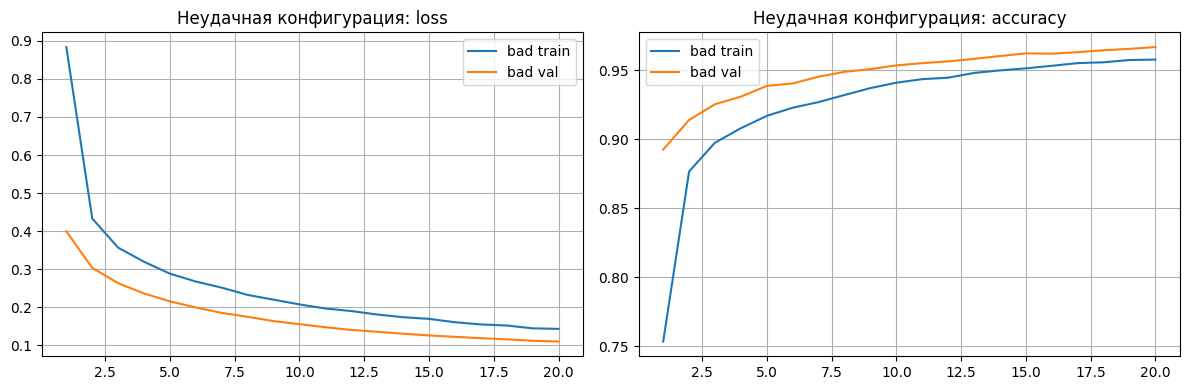

In [8]:
# Дополнительный Optuna-поиск
def objective_v2(trial: optuna.Trial):
    hidden_dim = trial.suggest_int("hidden_dim", 64, 512, step=64)
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    num_layers = trial.suggest_int("num_layers", 1, 2)

    layers = [nn.Flatten()]
    in_dim = 28 * 28
    for _ in range(num_layers):
        layers += [nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_p)]
        in_dim = hidden_dim
    layers.append(nn.Linear(hidden_dim, 10))

    model = nn.Sequential(*layers).to(device)

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    early_stopper = EarlyStopping(patience=5, min_delta=0.0)

    for epoch in range(1, 41):
        train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        if early_stopper.step(val_loss, model):
            break

    early_stopper.restore_best(model)
    _, final_val_acc = evaluate(model, val_loader, device)
    return final_val_acc

study_v2 = optuna.create_study(direction="maximize")
study_v2.optimize(objective_v2, n_trials=3, timeout=None)

print("Лучшее значение v2:", study_v2.best_value)
print("Лучшие параметры v2:")
for k, v in study_v2.best_params.items():
    print(" ", k, "=", v)

# Неудачная конфигурация (Trial 1 - низкий lr)
bad_model = SimpleMLP(hidden_dim=128, dropout_p=0.462).to(device)
bad_optimizer = torch.optim.Adam(bad_model.parameters(), lr=0.00013)
bad_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, 21):
    tl, ta = train_one_epoch(bad_model, train_loader, bad_optimizer, device)
    vl, va = evaluate(bad_model, val_loader, device)
    bad_history["train_loss"].append(tl)
    bad_history["val_loss"].append(vl)
    bad_history["train_acc"].append(ta)
    bad_history["val_acc"].append(va)
    if epoch % 5 == 0:
        print(f"[Bad] Эпоха {epoch}: train_acc={ta:.4f}, val_acc={va:.4f}")

epochs_arr = np.arange(1, 21)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_arr, bad_history["train_loss"], label="bad train")
plt.plot(epochs_arr, bad_history["val_loss"], label="bad val")
plt.title("Неудачная конфигурация: loss")
plt.grid(True); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs_arr, bad_history["train_acc"], label="bad train")
plt.plot(epochs_arr, bad_history["val_acc"], label="bad val")
plt.title("Неудачная конфигурация: accuracy")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()